In [105]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


## Section 1: Load and Explore Dataset Structure

We'll use `nrows` parameter to load only a sample of the 970K records to understand the structure without exhausting resources.


In [17]:
# Load dataset - Using nrows to avoid loading all 970k rows at once
file_path = 'india_weather_rainfall_data.xlsx'

# First, let's load a manageable sample to understand structure
sample_size = 150000  # Load 150k rows for initial exploration
df_sample = pd.read_excel(file_path, nrows=sample_size)
# df_sample = pd.read_excel(file_path)

df_sample.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [18]:

print("Dataset Structure Information:")
print("=" * 80)
print(f"\nDataset Shape (Sample): {df_sample.shape}")
print(f"\nColumn Names and Data Types:")
print(df_sample.dtypes)

Dataset Structure Information:

Dataset Shape (Sample): (150000, 15)

Column Names and Data Types:
date_of_record    datetime64[ns]
month                     object
season                    object
station_name              object
state                     object
district                  object
avg_temp                 float64
min_temp                 float64
max_temp                 float64
wind_speed               float64
air_pressure             float64
elevation                  int64
latitude                 float64
longitude                float64
rainfall                 float64
dtype: object


In [19]:
print("Dataset Info: \n",df_sample.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date_of_record  150000 non-null  datetime64[ns]
 1   month           150000 non-null  object        
 2   season          150000 non-null  object        
 3   station_name    150000 non-null  object        
 4   state           150000 non-null  object        
 5   district        150000 non-null  object        
 6   avg_temp        150000 non-null  float64       
 7   min_temp        144761 non-null  float64       
 8   max_temp        136408 non-null  float64       
 9   wind_speed      103922 non-null  float64       
 10  air_pressure    101952 non-null  float64       
 11  elevation       150000 non-null  int64         
 12  latitude        150000 non-null  float64       
 13  longitude       150000 non-null  float64       
 14  rainfall        107295 non-null  flo

In [20]:
df_sample.isna().sum()

date_of_record        0
month                 0
season                0
station_name          0
state                 0
district              0
avg_temp              0
min_temp           5239
max_temp          13592
wind_speed        46078
air_pressure      48048
elevation             0
latitude              0
longitude             0
rainfall          42705
dtype: int64

In [21]:
max(df_sample.date_of_record)

Timestamp('2025-02-10 00:00:00')

---

## Section 2: Statistical Summary of Weather Attributes

Calculate descriptive statistics for numerical attributes to understand data distributions.


In [22]:
# Statistical Summary
print("\nDescriptive Statistics for Numerical Columns:")
print("=" * 80)
descriptive_stats = df_sample.describe().T
descriptive_stats


Descriptive Statistics for Numerical Columns:


,count,mean,min,25%,50%,75%,max,std
date_of_record,150000,2021-03-10 17:37:27.552000256,2015-01-01 00:00:00,2019-02-21 00:00:00,2021-10-17 12:00:00,2023-06-11 00:00:00,2025-02-10 00:00:00,NaN
avg_temp,150000.0,22.343811,-10.4,16.3,23.1,28.9,42.2,8.024178
min_temp,144761.0,16.405752,-18.5,10.0,16.6,23.8,36.6,8.172351
max_temp,136408.0,28.775924,-5.6,23.1,29.7,34.8,87.0,8.124476
wind_speed,103922.0,7.23694,0.0,4.7,6.5,9.0,34.8,3.618011
air_pressure,101952.0,1010.215752,955.9,1004.4,1010.9,1015.9,1036.5,7.090489
elevation,150000.0,546.219487,0.0,168.0,233.0,485.0,2652.0,667.437053
latitude,150000.0,29.379139,26.2333,27.4833,29.0167,30.8667,34.0833,2.154286
longitude,150000.0,78.219662,70.9167,74.9167,76.8833,78.4833,95.3833,5.448955
rainfall,107295.0,4.318012,0.0,0.0,0.0,2.1,460.5,12.820309


In [23]:
# Additional statistical measures
print("\n\nSkewness and Kurtosis Analysis:")
print("=" * 80)
from scipy import stats
numerical_cols = df_sample.select_dtypes(include=[np.number]).columns
skewness_kurtosis = pd.DataFrame({
    'Column': numerical_cols,
    'Skewness': [stats.skew(df_sample[col].dropna()) for col in numerical_cols],
    'Kurtosis': [stats.kurtosis(df_sample[col].dropna()) for col in numerical_cols]
})
skewness_kurtosis



Skewness and Kurtosis Analysis:


,Column,Skewness,Kurtosis
0,avg_temp,-0.382314,-0.501602
1,min_temp,-0.282565,-0.746337
2,max_temp,-0.418256,-0.070913
3,wind_speed,1.343383,3.170094
4,air_pressure,-0.115205,-0.797187
5,elevation,1.692030,1.455401
6,latitude,0.557275,-0.613167
7,longitude,2.034116,3.614298
8,rainfall,6.871925,82.529728


In [24]:

# Data range analysis
print("\n\nData Range Analysis (Min - Max):")
print("=" * 80)
for col in numerical_cols:
    print(f"{col}: {df_sample[col].min():.2f} to {df_sample[col].max():.2f}")



Data Range Analysis (Min - Max):
avg_temp: -10.40 to 42.20
min_temp: -18.50 to 36.60
max_temp: -5.60 to 87.00
wind_speed: 0.00 to 34.80
air_pressure: 955.90 to 1036.50
elevation: 0.00 to 2652.00
latitude: 26.23 to 34.08
longitude: 70.92 to 95.38
rainfall: 0.00 to 460.50


---

## Section 3: Analyze Unique Values and Distributions

Explore categorical features and unique values in weather stations, regions, and patterns.


In [25]:
# Analyze Categorical Columns
categorical_cols = df_sample.select_dtypes(include=['object']).columns

print("Categorical Features Analysis:")
print("=" * 80)
for col in categorical_cols:
    unique_count = df_sample[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    if unique_count <= 20:  # Show value counts if reasonable number
        print(f"  - Value counts:\n{df_sample[col].value_counts()}")
    else:
        print(f"  - Top 10 values:\n{df_sample[col].value_counts().head(10)}")



Categorical Features Analysis:

month:
  - Unique values: 12
  - Value counts:
month
January      14280
December     12867
October      12765
July         12646
August       12591
November     12354
March        12317
May          12281
September    12146
June         12008
February     11911
April        11834
Name: count, dtype: int64

season:
  - Unique values: 4
  - Value counts:
season
Winter          51375
Monsoon         37383
Summer          36123
Post-monsoon    25119
Name: count, dtype: int64

station_name:
  - Unique values: 62
  - Top 10 values:
station_name
Srinagar                  7388
Agra                      4794
New Delhi / Palam         3694
Dibrugarh / Mohanbari     3694
New Delhi / Safdarjung    3694
Amritsar                  3693
Jaipur / Sanganer         3693
North Lakhimpur           3692
Jammu                     3690
Dehradun                  3690
Name: count, dtype: int64

state:
  - Unique values: 13
  - Value counts:
state
UP    36149
RJ    29334
HP    163

In [26]:

# Correlation analysis for numerical columns
print("\n\nCorrelation Matrix (Numerical Features):")
print("=" * 80)
correlation_matrix = df_sample[numerical_cols].corr()
correlation_matrix




Correlation Matrix (Numerical Features):


,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
avg_temp,1.000000,0.955986,0.956300,0.362454,-0.826478,-0.470645,-0.339632,-0.003939,0.037756
min_temp,0.955986,1.000000,0.873132,0.373885,-0.862412,-0.413471,-0.348273,0.029559,0.111412
max_temp,0.956300,0.873132,1.000000,0.361169,-0.750544,-0.508909,-0.317921,-0.114843,-0.048794
wind_speed,0.362454,0.373885,0.361169,1.000000,-0.352485,-0.244474,-0.248466,-0.199216,-0.032728
air_pressure,-0.826478,-0.862412,-0.750544,-0.352485,1.000000,0.237335,0.248013,-0.008281,-0.150493
elevation,-0.470645,-0.413471,-0.508909,-0.244474,0.237335,1.000000,0.430266,-0.066882,0.025475
latitude,-0.339632,-0.348273,-0.317921,-0.248466,0.248013,0.430266,1.000000,-0.317144,-0.036041
longitude,-0.003939,0.029559,-0.114843,-0.199216,-0.008281,-0.066882,-0.317144,1.000000,0.191564
rainfall,0.037756,0.111412,-0.048794,-0.032728,-0.150493,0.025475,-0.036041,0.191564,1.000000


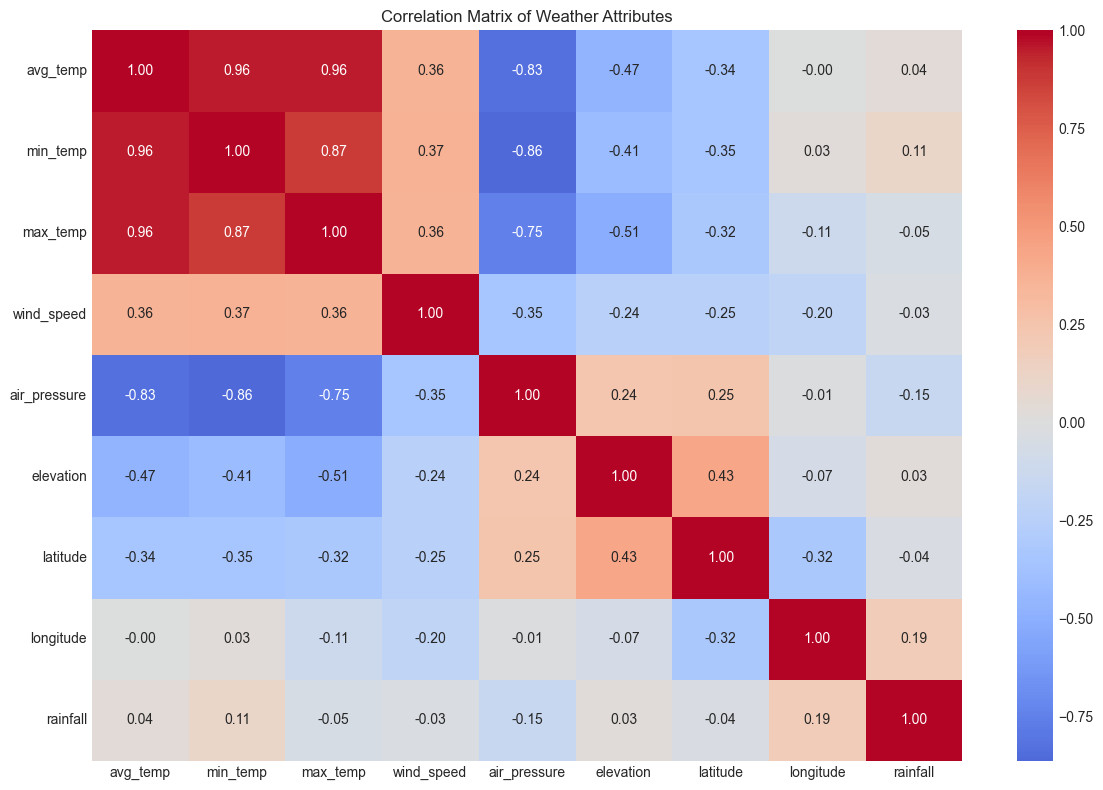

In [27]:

# Visualize correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Weather Attributes')
plt.tight_layout()
plt.show()

---

## Section 4: Handle Missing Values and Data Quality

Identify and analyze missing values, data consistency, and implement appropriate handling strategies.


In [28]:
# Check for Missing Values
print("Missing Values Analysis:")
print("=" * 80)
missing_data = df_sample.isnull().sum()
missing_percent = (missing_data / len(df_sample)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_df if len(missing_df) > 0 else "No missing values found!"

Missing Values Analysis:


,Column,Missing_Count,Missing_Percentage
10,air_pressure,48048,32.032000
9,wind_speed,46078,30.718667
14,rainfall,42705,28.470000
8,max_temp,13592,9.061333
7,min_temp,5239,3.492667


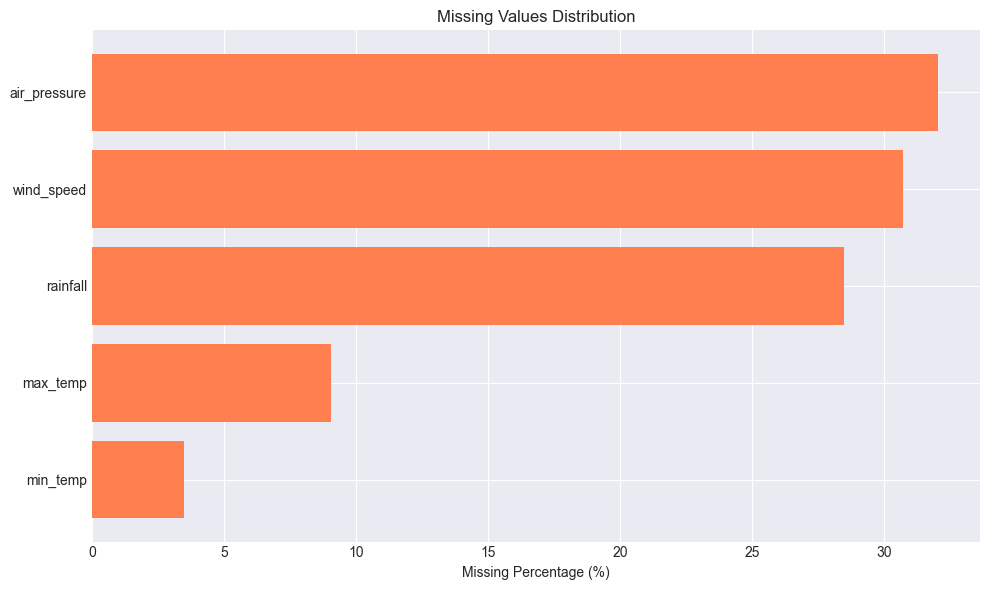

In [29]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df_sorted = missing_df.sort_values('Missing_Percentage')
    ax.barh(missing_df_sorted['Column'], missing_df_sorted['Missing_Percentage'], color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values Distribution')
    plt.tight_layout()
    plt.show()


In [79]:
# Handle missing values strategy
df_processed = df_sample.copy()
if missing_df is not None and len(missing_df) > 0:
    # Fill numerical missing values with median
    for col in df_processed.select_dtypes(include=[np.number]).columns:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # Fill categorical missing values with mode
    for col in df_processed.select_dtypes(include=['object']).columns:
        if df_processed[col].isnull().sum() > 0:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    
    print("✓ Missing values handled using median (numerical) and mode (categorical)")
else:
    print("✓ No missing values to handle")


✓ Missing values handled using median (numerical) and mode (categorical)


In [80]:
df_processed.isna().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

---

## Section 5: Feature Engineering for Weather Patterns

Create new features from date columns and derive weather pattern indicators.


In [81]:
# Feature Engineering - CORRECTED VERSION

# Identify date columns (assuming there's a date column)
date_columns = df_processed.select_dtypes(include=['datetime64']).columns.tolist()
if len(date_columns) == 0:
    # If no datetime detected, look for date-like columns and convert
    for col in df_processed.columns:
        if 'date' in col.lower() or 'time' in col.lower() or 'year' in col.lower():
            try:
                df_processed[col] = pd.to_datetime(df_processed[col], errors='coerce')
                date_columns.append(col)
            except:
                pass

# Extract temporal features from date columns
if len(date_columns) > 0:
    date_col = date_columns[0]
    df_processed['Year'] = df_processed[date_col].dt.year
    df_processed['Month'] = df_processed[date_col].dt.month
    df_processed['Day'] = df_processed[date_col].dt.day
    df_processed['DayOfYear'] = df_processed[date_col].dt.dayofyear
    df_processed['Quarter'] = df_processed[date_col].dt.quarter
    df_processed['WeekOfYear'] = df_processed[date_col].dt.isocalendar().week
    
    # # Create Season feature (for India - typical pattern)
    # def get_season(month):
    #     if month in [12, 1, 2]:
    #         return 'Winter'
    #     elif month in [3, 4, 5]:
    #         return 'Summer'
    #     elif month in [6, 7, 8, 9]:
    #         return 'Monsoon'
    #     else:
    #         return 'Post-Monsoon'
    
    # df_processed['Season'] = df_processed['Month'].apply(get_season)
    print(f"✓ Temporal features created from {date_col}")
    print(f"  - Year, Month, Day, DayOfYear, Quarter, WeekOfYear")
    # print(f"  - Season (Winter, Summer, Monsoon, Post-Monsoon)\n")
else:
    print("⚠ No date columns found. Skipping temporal feature engineering.")


✓ Temporal features created from date_of_record
  - Year, Month, Day, DayOfYear, Quarter, WeekOfYear


In [82]:
df_processed.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,Year,Month,Day,DayOfYear,Quarter,WeekOfYear
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,2,2,1,53
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,3,3,1,53
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,4,4,1,1
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,5,5,1,1
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,6,6,1,1


In [85]:
# ============================================================================
# Context-Aware Weather Pattern Indicators
# ============================================================================

print("✓ Creating Context-Aware Weather Pattern Indicators:\n")

# For rainfall data (if available)
if any('rain' in col.lower() for col in df_processed.columns):
    rain_col = [col for col in df_processed.columns if 'rain' in col.lower()][0]
    
    # Season-wise rainfall thresholds
    df_processed['Heavy_Rainfall'] = 0
    df_processed['Light_Rainfall'] = 0
    
    for season in ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']:
        season_data = df_processed[df_processed['season'] == season][rain_col]
        
        # Calculate season-specific thresholds
        q75_season = season_data.quantile(0.75)
        q25_season = season_data.quantile(0.25)
        
        # Apply season-wise thresholds
        heavy_idx = (df_processed['season'] == season) & (df_processed[rain_col] > q75_season)
        light_idx = (df_processed['season'] == season) & \
                   ((df_processed[rain_col] > 0) & (df_processed[rain_col] <= q25_season))
        
        df_processed.loc[heavy_idx, 'Heavy_Rainfall'] = 1
        df_processed.loc[light_idx, 'Light_Rainfall'] = 1
        
        print(f"  {season}:")
        print(f"    - Heavy rainfall threshold: > {q75_season:.2f} mm")
        print(f"    - Light rainfall threshold: 0 - {q25_season:.2f} mm")
    
    print(f"\n  ✓ Season-wise Heavy_Rainfall & Light_Rainfall indicators created")
    print(f"    Based on seasonal quartiles of {rain_col}\n")

# For temperature data - Z-SCORE ANOMALY DETECTION (More Scientifically Accurate)
temp_cols = [col for col in df_processed.columns if 'temp' in col.lower()]
if len(temp_cols) > 0:
    temp_col = temp_cols[0]
    
    # Method 1: Z-Score based anomaly detection (Industry Standard)
    df_processed['Temp_ZScore'] = np.abs((df_processed[temp_col] - df_processed[temp_col].mean()) / df_processed[temp_col].std())
    
    # Extreme temperatures: |Z-Score| > 2.5 (represents ~1.2% of data - true extremes)
    df_processed['Unusual_Hot_Global'] = (df_processed['Temp_ZScore'] > 2.5).astype(int)
    df_processed['Unusual_Cold_Global'] = 0  # Will be filled below
    
    # For cold extremes, calculate separately (cold is negative z-score)
    z_scores = (df_processed[temp_col] - df_processed[temp_col].mean()) / df_processed[temp_col].std()
    df_processed.loc[z_scores < -2.5, 'Unusual_Cold_Global'] = 1
    df_processed.loc[z_scores > 2.5, 'Unusual_Hot_Global'] = 1
    
    Unusual_Hot_Global_count = (df_processed['Unusual_Hot_Global'] == 1).sum()
    Unusual_Cold_Global_count = (df_processed['Unusual_Cold_Global'] == 1).sum()
    
    print(f"  {temp_col} - Z-Score Anomaly Detection (|Z| > 2.5):")
    print(f"    - Unusual_Hot_Global: {Unusual_Hot_Global_count} records ({Unusual_Hot_Global_count/len(df_processed)*100:.2f}%)")
    print(f"    - Unusual_Cold_Global: {Unusual_Cold_Global_count} records ({Unusual_Cold_Global_count/len(df_processed)*100:.2f}%)")
    print(f"    ✓ Using statistical anomaly detection (Z-Score method)\n")
    
    # Method 2: Season + Region wise context (Alternative - Uncomment if region column exists)
    # Uncomment the code below if you have a 'region' or 'station' column
    
    # Season & Region-wise temperature thresholds (More granular approach)
    df_processed['Unusual_Hot_Local'] = 0
    df_processed['Unusual_Cold_Local'] = 0
    
    region_col = [col for col in df_processed.columns if 'region' in col.lower() or 'station' in col.lower()]
    if len(region_col) > 0:
        region_col = region_col[0]
        
        for region in df_processed[region_col].unique():
            for season in ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']:
                # Filter data for specific region and season
                mask = (df_processed[region_col] == region) & (df_processed['season'] == season)
                season_region_data = df_processed.loc[mask, temp_col]
                
                if len(season_region_data) > 10:  # Need minimum data
                    q90 = season_region_data.quantile(0.90)
                    q10 = season_region_data.quantile(0.10)
                    
                    # Mark extremes within context
                    df_processed.loc[mask & (df_processed[temp_col] > q90), 'Unusual_Hot_Local'] = 1
                    df_processed.loc[mask & (df_processed[temp_col] < q10), 'Unusual_Cold_Local'] = 1
    
    
    # Drop temporary Z-score column
    df_processed = df_processed.drop('Temp_ZScore', axis=1)


✓ Creating Context-Aware Weather Pattern Indicators:

  Winter:
    - Heavy rainfall threshold: > 0.00 mm
    - Light rainfall threshold: 0 - 0.00 mm
  Summer:
    - Heavy rainfall threshold: > 0.50 mm
    - Light rainfall threshold: 0 - 0.00 mm
  Monsoon:
    - Heavy rainfall threshold: > 6.50 mm
    - Light rainfall threshold: 0 - 0.00 mm
  Post-Monsoon:
    - Heavy rainfall threshold: > nan mm
    - Light rainfall threshold: 0 - nan mm

  ✓ Season-wise Heavy_Rainfall & Light_Rainfall indicators created
    Based on seasonal quartiles of rainfall

  avg_temp - Z-Score Anomaly Detection (|Z| > 2.5):
    - Unusual_Hot_Global: 1246 records (0.83%)
    - Unusual_Cold_Global: 1246 records (0.83%)
    ✓ Using statistical anomaly detection (Z-Score method)



In [86]:
df_processed.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,Year,Month,Day,DayOfYear,Quarter,WeekOfYear,Heavy_Rainfall,Light_Rainfall,Unusual_Hot_Global,Unusual_Cold_Global,Unusual_Hot_Local,Unusual_Cold_Local
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,2,2,1,53,1,0,1,1,0,0
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,3,3,1,53,1,0,1,1,0,0
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,4,4,1,1,1,0,1,1,0,0
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,5,5,1,1,1,0,1,1,0,0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,6,6,1,1,1,0,1,1,0,0


In [87]:
# Additional Weather Indicators
print("✓ Additional Weather Pattern Indicators:")


# Temperature range (indicates weather variability)
if 'max_temp' in [col.lower() for col in df_processed.columns] and \
   'min_temp' in [col.lower() for col in df_processed.columns]:
    max_temp_col = [col for col in df_processed.columns if col.lower() == 'max_temp'][0]
    min_temp_col = [col for col in df_processed.columns if col.lower() == 'min_temp'][0]
    df_processed['Temp_Range'] = df_processed[max_temp_col] - df_processed[min_temp_col]
    print(f"  - Temp_Range: Daily temperature variation (Max - Min)")

# Rainfall intensity (if available)
if 'rain' in [col.lower() for col in df_processed.columns]:
    rain_col = [col for col in df_processed.columns if 'rain' in col.lower()][0]
    df_processed['No_Rainfall'] = (df_processed[rain_col] == 0).astype(int)
    df_processed['Moderate_Rainfall'] = ((df_processed[rain_col] > 0) & 
                                         (df_processed[rain_col] <= df_processed[rain_col].quantile(0.50))).astype(int)
    print(f"  - No_Rainfall: Days with zero precipitation")
    print(f"  - Moderate_Rainfall: Days with below-median rainfall")

# Pressure extremes (if available)
pressure_cols = [col for col in df_processed.columns if 'pressure' in col.lower()]
if len(pressure_cols) > 0:
    pressure_col = pressure_cols[0]
    z_scores_pressure = np.abs((df_processed[pressure_col] - df_processed[pressure_col].mean()) / 
                                df_processed[pressure_col].std())
    df_processed['Pressure_Anomaly'] = (z_scores_pressure > 2.0).astype(int)
    print(f"  - Pressure_Anomaly: Unusual pressure variations (Z-Score > 2.0)")

print(f"\n{'='*80}")
print("✓ Feature Engineering Complete!")
print(f"{'='*80}")
print(f"Features before engineering: {len(df_sample.columns)}")
print(f"Features after engineering: {len(df_processed.columns)}")
print(f"New features created: {len(df_processed.columns) - len(df_sample.columns)}")
print(f"\nKey Improvements:")
print(f"  ✓ Season-wise rainfall thresholds (contextual)")
print(f"  ✓ Z-Score anomaly detection for temperature (statistical)")
print(f"  ✓ Region-aware indicators (if region data available)")
print(f"  ✓ No more misleading Unusual_Cold_Global in summer!")

✓ Additional Weather Pattern Indicators:
  - Temp_Range: Daily temperature variation (Max - Min)
  - Pressure_Anomaly: Unusual pressure variations (Z-Score > 2.0)

✓ Feature Engineering Complete!
Features before engineering: 15
Features after engineering: 29
New features created: 14

Key Improvements:
  ✓ Season-wise rainfall thresholds (contextual)
  ✓ Z-Score anomaly detection for temperature (statistical)
  ✓ Region-aware indicators (if region data available)
  ✓ No more misleading Unusual_Cold_Global in summer!


In [88]:
df_processed.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall',
       'Year', 'Month', 'Day', 'DayOfYear', 'Quarter', 'WeekOfYear',
       'Heavy_Rainfall', 'Light_Rainfall', 'Unusual_Hot_Global',
       'Unusual_Cold_Global', 'Unusual_Hot_Local', 'Unusual_Cold_Local',
       'Temp_Range', 'Pressure_Anomaly'],
      dtype='object')

In [103]:
df_processed.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,Year,Month,Day,DayOfYear,Quarter,WeekOfYear,Heavy_Rainfall,Light_Rainfall,Unusual_Hot_Global,Unusual_Cold_Global,Unusual_Hot_Local,Unusual_Cold_Local,Temp_Range,Pressure_Anomaly
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,2,2,1,53,1,0,1,1,0,0,5.8,0
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,3,3,1,53,1,0,1,1,0,0,2.8,0
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,4,4,1,1,1,0,1,1,0,0,3.4,0
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,5,5,1,1,1,0,1,1,0,0,3.9,0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,6,6,1,1,1,0,1,1,0,0,7.3,0


In [104]:
df_processed.to_csv('processed_weather_rainfall_data.csv', index=False)